In [1]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from scipy.stats import linregress
from tools import *

In [2]:
file_path = f'/Users/kellyhui/Downloads/RBG_data/4_15_26/KH_RBG_otr_041526_KF_P6_post_anc.csv'
df = pd.read_csv(f'{file_path}') 
df_anc = clean_and_transpose(df, 25, 63).dropna().transpose()
df_anc = df_anc.reset_index()
df_anc.columns = ['Well', 'OD']

def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)
    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD']]

tidy_anc = tidy_plate(df_anc, 7)
tidy_anc = tidy_anc.loc[tidy_anc['BioRep'] != 'D']
bio_rep_anc = tidy_anc.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() 

dataframes = []
for i in range(1, 7):
    file_path = f'/Users/kellyhui/Downloads/RBG_data/4_15_26/KH_RBG_otr_041526_KF_P6_post_{i}.csv'
    df = pd.read_csv(f'{file_path}') 
    df = clean_and_transpose(df, 24, 122).dropna().transpose()
    df = df.reset_index()
    df.columns = ['Well', 'OD']
    dataframes.append(df)

#assign phage doses
def tidy_plate(df, plate_num):

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)

    H_mean = df[df['BioRep'] == 'H']['OD'].mean()
    print(H_mean)
    df['OD_subtracted'] = df['OD'] - H_mean

    df = df[df['BioRep'] != 'H']

    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD', 'OD_subtracted']]

tbl_arr = [tidy_plate(dataframes[i], i+1) for i in range(6)]
tbl_arr.append(tidy_anc)

#group plate, biol rep, and dose
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
#bio_rep_mean.append(bio_rep_anc)

plate_results = []

for df in tbl_arr:
    df = df.copy()

    # log transform (handle 0)
    df["Dose_log"] = np.log10(df["Dose"] + 0.01)

    x = df["Dose_log"].values
    y = df["OD"].values

    if len(x) < 2:
        continue

    slope, intercept, r_value, p_value, _ = linregress(x, y)

    plate_results.append({
        "Plate": df["Plate"].iloc[0],
        "R2": r_value**2,
        "p_value": p_value,
        "slope": slope
    })

plate_table = pd.DataFrame(plate_results)
plate_table 

0.17489166683333335
0.21074166758333338
0.22228333349999999
0.31490000341666663
0.23194999874999997
0.22759166849999998


,Plate,R2,p_value,slope
0,1,0.000700,0.811199,0.000723
1,2,0.013021,0.301358,-0.004239
2,3,0.016497,0.244267,-0.005055
3,4,0.035805,0.084728,-0.006766
4,5,0.002716,0.637754,-0.000937
5,6,0.024813,0.152423,-0.006535
6,7,0.617887,0.000001,-0.022826


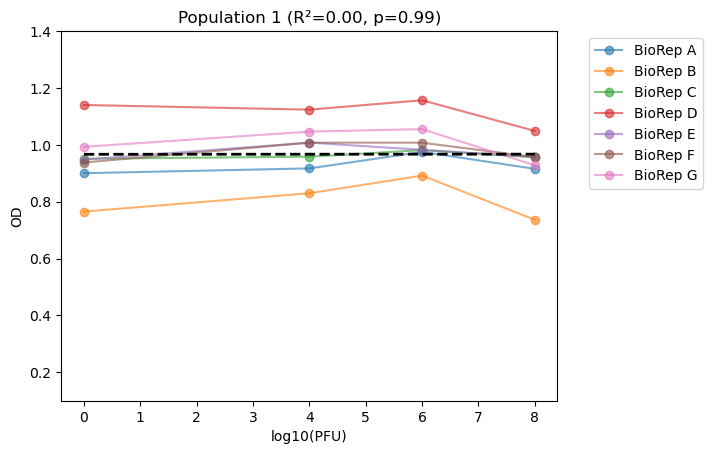

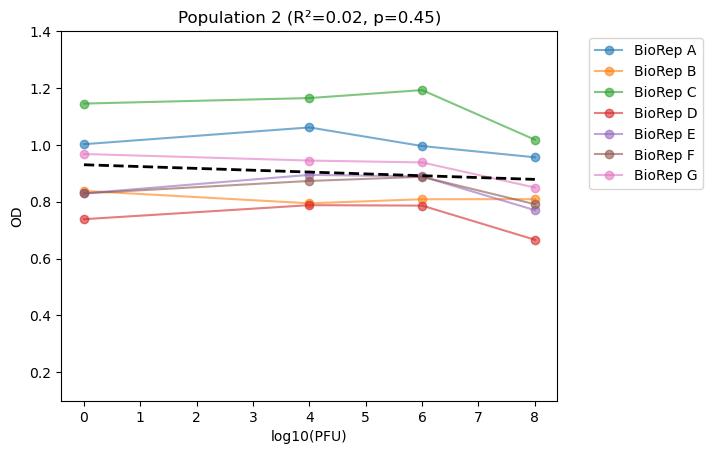

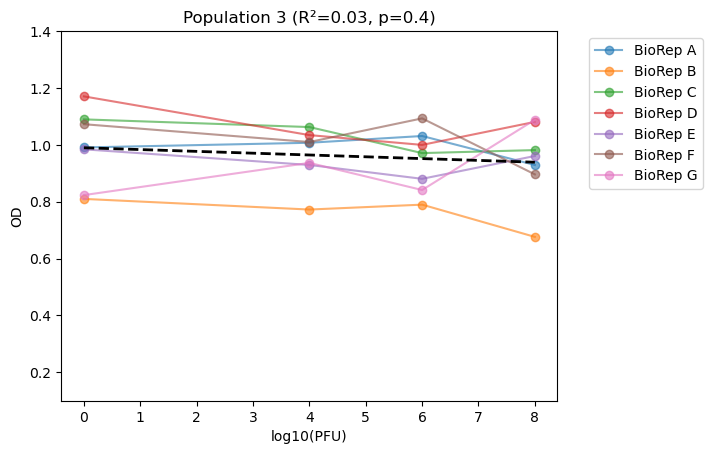

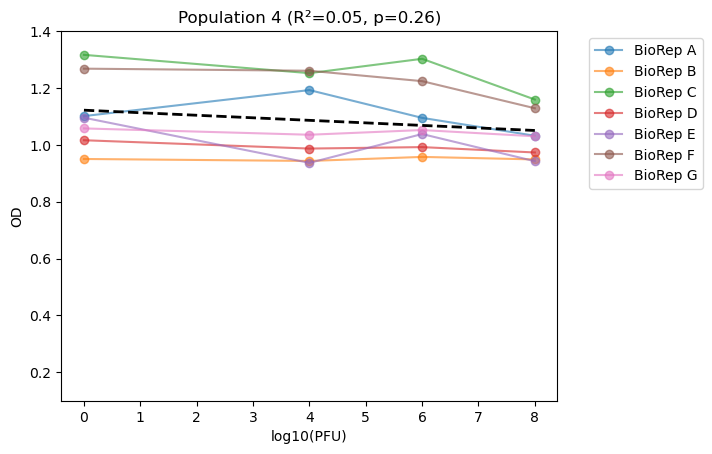

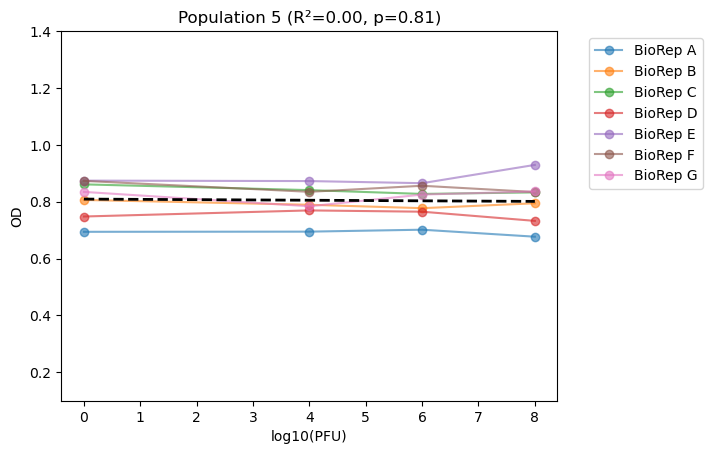

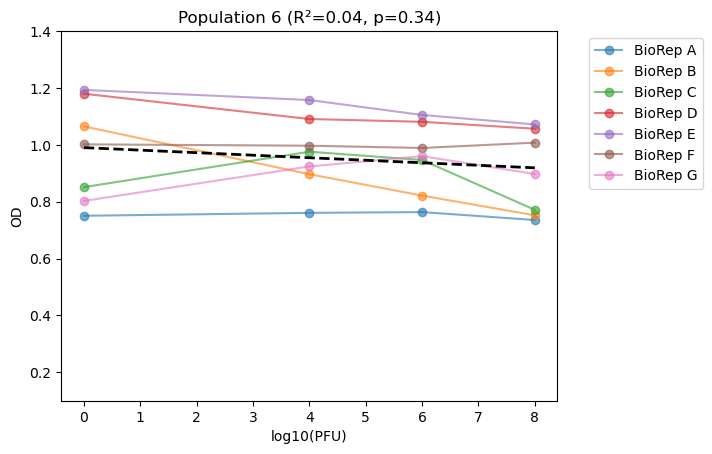

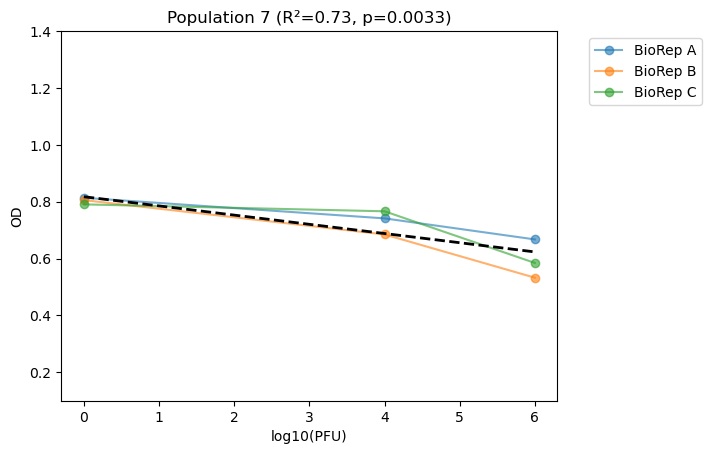

In [3]:
for i, df in enumerate(bio_rep_mean):
    plt.figure()

    df = df.copy()
    df['Dose_plot'] = df['Dose'].apply(lambda x: 0 if x == 0 else np.log10(x))

    x_all = df['Dose_plot'].values
    y_all = df['OD'].values

    slope, intercept, r_value, p_value, _ = linregress(x_all, y_all)
    r2 = r_value**2

    #plot each BioRep
    for bio in df['BioRep'].unique():
        bio_df = df[df['BioRep'] == bio]

        plt.plot(
            bio_df['Dose_plot'],
            bio_df['OD'],
            marker='o',
            alpha=0.6,
            label=f'BioRep {bio}'
        )


    #plot the regression line
    x_line = np.linspace(min(x_all), max(x_all), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, linestyle='--', linewidth=2, color='black')

    # --- labels ---
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(
        f'Population {i+1} (R²={r2:.2f}, p={p_value:.2g})'
    )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0.1, 1.4)

    plt.show()

In [4]:
for i, df in enumerate(dataframes):
    df.to_csv(f"TK_P6_2_{i}.csv", index=False)

In [11]:
bio_rep_mean = [tbl.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean() for tbl in tbl_arr]
combined_df = pd.concat(bio_rep_mean, ignore_index=True)
combined_df = combined_df[combined_df['Plate'] != 7]
variance_summary = (
    combined_df
    .groupby(['Plate', 'Dose'])
    .agg(
        mean_OD=('OD', 'mean'),
        variance_OD=('OD', 'var'),
        sd_OD=('OD', 'std')
    )
    .reset_index()
)

variance_summary['CV'] = (
    variance_summary['sd_OD'] /
    variance_summary['mean_OD']
)

variance_summary
#variance_summary.groupby(['Strain','Passage'])['CV'].mean()

,Plate,Dose,mean_OD,variance_OD,sd_OD,CV
0,1,0.0,0.948000,0.012458,0.111616,0.117738
1,1,10000.0,0.984462,0.008913,0.094410,0.095901
2,1,1000000.0,1.007271,0.006721,0.081979,0.081387
3,1,100000000.0,0.928481,0.008995,0.094841,0.102146
4,2,0.0,0.907181,0.019118,0.138267,0.152414
5,2,10000.0,0.931462,0.019260,0.138782,0.148993
6,2,1000000.0,0.928276,0.018702,0.136754,0.147320
7,2,100000000.0,0.837286,0.013944,0.118085,0.141033
8,3,0.0,0.991552,0.018259,0.135128,0.136279
9,3,10000.0,0.964624,0.009549,0.097720,0.101304
